In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

In [26]:


# Load the dataset
df_model = pd.read_csv("Sydney_Housing_ML_Dataset.csv")

print("Dataset loaded successfully.")
print("Shape:", df_model.shape)
print("\nColumns:")
print(df_model.columns.tolist())

Dataset loaded successfully.
Shape: (122, 16)

Columns:
['Property_ID_Raw', 'Sale_Counter', 'Street_Number', 'Street_Name', 'Suburb', 'Postcode', 'Land Size', 'Contract_Date', 'Settlement_Date', 'Sale_Price', 'Zoning', 'Property_type', 'Dealing_Number', 'Contract_Year', 'Days_to_Settlement', 'Land Size Original']


In [27]:
print(df_model.head())
print("\nMissing values:")
print(df_model.isnull().sum())
print("\nData types:")
print(df_model.dtypes)

   Property_ID_Raw  Sale_Counter Street_Number     Street_Name     Suburb  \
0          3410896             2            31       THIRD AVE  Blacktown   
1          4166943             7             3     BALMORAL ST  Blacktown   
2          6066721            25             9  HIGHLANDS CRES  Blacktown   
3          6044673            30            99      STEPHEN ST  Blacktown   
4          2166863            85            28   CAVENDISH AVE  Blacktown   

   Postcode  Land Size Contract_Date Settlement_Date  Sale_Price Zoning  \
0      2148      556.4    2026-07-05      2026-08-17      420000    NaN   
1      2148      104.0    2026-07-05      2026-08-14      600000    NaN   
2      2148      238.0    2025-03-29      2026-08-20      950000    NaN   
3      2148      512.0    2025-11-07      2026-04-01     1495000     R2   
4      2148      556.4    2026-07-06      2026-08-17     1110000     R2   

  Property_type Dealing_Number  Contract_Year  Days_to_Settlement  \
0     RESIDENCE  

In [28]:
# Compare sale price by suburb
suburb_analysis = df_model.groupby("Suburb")["Sale_Price"].agg(
    ["count", "mean", "median", "min", "max"]
)

print("Sale Price by Suburb:")
print(suburb_analysis)

Sale Price by Suburb:
            count          mean     median     min      max
Suburb                                                     
Blacktown      45  8.616222e+05   920000.0  410000  1881000
Chatswood      37  2.359892e+06  2420000.0  647000  4600000
Parramatta     40  6.282028e+05   612500.0  312000  1300000


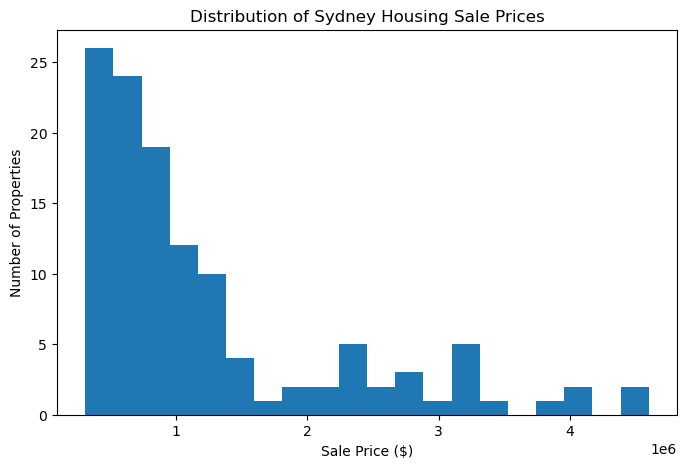

In [29]:
plt.figure(figsize=(8, 5))
plt.hist(df_model["Sale_Price"], bins=20)
plt.xlabel("Sale Price ($)")
plt.ylabel("Number of Properties")
plt.title("Distribution of Sydney Housing Sale Prices")
plt.show()

In [30]:
# Average sale price by contract year
year_analysis = df_model.groupby("Contract_Year")["Sale_Price"].agg(
    ["count", "mean", "median"]
)

print("Sale Price by Contract Year:")
print(year_analysis)

Sale Price by Contract Year:
               count          mean     median
Contract_Year                                
2022               7  2.848571e+06  2795000.0
2023               3  2.750000e+06  2250000.0
2024               1  3.100000e+06  3100000.0
2025               3  1.146000e+06   993000.0
2026             108  1.078603e+06   790000.0


In [31]:
# Identify potential sale-price outliers using the IQR method

Q1 = df_model["Sale_Price"].quantile(0.25)
Q3 = df_model["Sale_Price"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_model[
    (df_model["Sale_Price"] < lower_bound) |
    (df_model["Sale_Price"] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Number of potential outliers:", len(outliers))

print("\nPotential price outliers:")
print(outliers[
    ["Property_ID_Raw", "Street_Number", "Street_Name",
     "Suburb", "Land Size", "Sale_Price", "Property_type", "Zoning"]
].sort_values("Sale_Price"))

Q1: 570500.0
Q3: 1385000.0
IQR: 814500.0
Lower bound: -651250.0
Upper bound: 2606750.0
Number of potential outliers: 16

Potential price outliers:
     Property_ID_Raw Street_Number      Street_Name     Suburb  Land Size  \
51           3343003             1   CAMBRIDGE LANE  Chatswood     170.00   
80           6041724            15         ELLIS ST  Chatswood     185.00   
115           954176            28        CLAUDE ST  Chatswood     170.00   
82           6041724            15         ELLIS ST  Chatswood     154.00   
87           6041724            15         ELLIS ST  Chatswood     156.00   
84           6041724            15         ELLIS ST  Chatswood     143.00   
92            958731             5        GIBBES ST  Chatswood    1170.00   
94            971187             5       SPENCER PL  Chatswood     714.50   
114           951381            91  BEACONSFIELD RD  Chatswood     736.50   
86           6041724            15         ELLIS ST  Chatswood     155.00   
117   

In [32]:
# Examine the relationship between land size and sale price

print("Correlation between Land Size and Sale Price:")

correlation = df_model["Land Size"].corr(df_model["Sale_Price"])

print(correlation)

Correlation between Land Size and Sale Price:
0.26510831259437195


In [33]:

# Load the CSV
df = pd.read_csv("Sydney_Housing_ML_Dataset.csv")

# Create the ML dataset from the cleaned residential data
df_ml = df[df["Property_type"] == "RESIDENCE"].copy()

# Convert dates
df_ml["Contract_Date"] = pd.to_datetime(df_ml["Contract_Date"])

# Create time features
df_ml["Contract_Year"] = df_ml["Contract_Date"].dt.year
df_ml["Contract_Month"] = df_ml["Contract_Date"].dt.month

# Keep the columns currently required for ML
df_ml = df_ml[
    ["Suburb", "Land Size", "Contract_Date",
     "Zoning", "Sale_Price", "Contract_Year", "Contract_Month"]
].copy()

print("df_ml shape:", df_ml.shape)
print(df_ml.head())

df_ml shape: (122, 7)
      Suburb  Land Size Contract_Date Zoning  Sale_Price  Contract_Year  \
0  Blacktown      556.4    2026-07-05    NaN      420000           2026   
1  Blacktown      104.0    2026-07-05    NaN      600000           2026   
2  Blacktown      238.0    2025-03-29    NaN      950000           2025   
3  Blacktown      512.0    2025-11-07     R2     1495000           2025   
4  Blacktown      556.4    2026-07-06     R2     1110000           2026   

   Contract_Month  
0               7  
1               7  
2               3  
3              11  
4               7  


In [34]:
# Create log-transformed land size
df_ml["Log_Land_Size"] = np.log1p(df_ml["Land Size"])

print(df_ml[["Land Size", "Log_Land_Size"]].head())

print("\nUpdated shape:", df_ml.shape)
print(df_ml[["Land Size", "Log_Land_Size"]].describe())

   Land Size  Log_Land_Size
0      556.4       6.323283
1      104.0       4.653960
2      238.0       5.476464
3      512.0       6.240276
4      556.4       6.323283

Updated shape: (122, 8)
         Land Size  Log_Land_Size
count   122.000000     122.000000
mean    313.664426       5.415502
std     268.583981       0.809875
min      65.000000       4.189655
25%     104.500000       4.658711
50%     170.000000       5.141664
75%     556.400000       6.323283
max    1397.000000       7.242798


In [35]:
# Part 2: Feature Engineering
# Create engineered dataset and encode categorical variables


# Work from the existing ML dataset
df_engineered = df_ml.copy()

# Log transformation of Land Size
df_engineered["Log_Land_Size"] = np.log1p(df_engineered["Land Size"])

# One-hot encode Suburb and Zoning
df_engineered = pd.get_dummies(
    df_engineered,
    columns=["Suburb", "Zoning"],
    drop_first=False,
    dtype=float
)

# Check the final engineered dataset
print("Engineered dataset shape:", df_engineered.shape)

print("\nColumns:")
print(df_engineered.columns.tolist())

print("\nMissing values:")
print(df_engineered.isnull().sum())

print("\nFirst 5 rows:")
display(df_engineered.head())

Engineered dataset shape: (122, 13)

Columns:
['Land Size', 'Contract_Date', 'Sale_Price', 'Contract_Year', 'Contract_Month', 'Log_Land_Size', 'Suburb_Blacktown', 'Suburb_Chatswood', 'Suburb_Parramatta', 'Zoning_C4', 'Zoning_E4', 'Zoning_R1', 'Zoning_R2']

Missing values:
Land Size            0
Contract_Date        0
Sale_Price           0
Contract_Year        0
Contract_Month       0
Log_Land_Size        0
Suburb_Blacktown     0
Suburb_Chatswood     0
Suburb_Parramatta    0
Zoning_C4            0
Zoning_E4            0
Zoning_R1            0
Zoning_R2            0
dtype: int64

First 5 rows:


,Land Size,Contract_Date,Sale_Price,Contract_Year,Contract_Month,Log_Land_Size,Suburb_Blacktown,Suburb_Chatswood,Suburb_Parramatta,Zoning_C4,Zoning_E4,Zoning_R1,Zoning_R2
0,556.4,2026-07-05,420000,2026,7,6.323283,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,104.0,2026-07-05,600000,2026,7,4.653960,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,238.0,2025-03-29,950000,2025,3,5.476464,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,512.0,2025-11-07,1495000,2025,11,6.240276,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,556.4,2026-07-06,1110000,2026,7,6.323283,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [36]:
# Part 3: Model Development and Evaluation
# Three regression models with 5-fold cross-validation

# Prepare X and y
X = df_engineered.drop(columns=["Sale_Price", "Contract_Date"])
y = df_engineered["Sale_Price"]

# Define three different regression approaches
models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    
    "Decision Tree": DecisionTreeRegressor(
        max_depth=5,
        random_state=42
    ),
    
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=8,
        random_state=42
    )
}

# 5-fold cross-validation
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Evaluate models
results = []

for name, model in models.items():
    
    scores = cross_validate(
        model,
        X,
        y,
        cv=kf,
        scoring={
            "MAE": "neg_mean_absolute_error",
            "RMSE": "neg_root_mean_squared_error",
            "R2": "r2"
        },
        return_train_score=True
    )
    
    results.append({
        "Model": name,
        "CV MAE": -scores["test_MAE"].mean(),
        "CV RMSE": -scores["test_RMSE"].mean(),
        "CV R2": scores["test_R2"].mean(),
        "Training R2": scores["train_R2"].mean()
    })

results_df = pd.DataFrame(results)

print("5-Fold Cross-Validation Results:")
display(results_df.round(2))

5-Fold Cross-Validation Results:


,Model,CV MAE,CV RMSE,CV R2,Training R2
0,Linear Regression,382373.29,516522.15,0.66,0.79
1,Decision Tree,363260.51,551654.58,0.66,0.94
2,Random Forest,316583.79,470585.27,0.76,0.94


In [37]:
# Part 4: Investigating Prediction Failures
# Train the Random Forest and identify the five largest prediction errors

# Use the same features as the cross-validation stage
X = df_engineered.drop(columns=["Sale_Price", "Contract_Date"])
y = df_engineered["Sale_Price"]

# Keep the original row index so we can identify the properties later
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

# Train the recommended Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

rf_model.fit(X_train, y_train)

# Predictions
y_pred = rf_model.predict(X_test)

# Calculate errors
error_df = pd.DataFrame({
    "Actual_Price": y_test,
    "Predicted_Price": y_pred
})

error_df["Absolute_Error"] = abs(
    error_df["Actual_Price"] - error_df["Predicted_Price"]
)

error_df["Percentage_Error"] = (
    error_df["Absolute_Error"] /
    error_df["Actual_Price"]
) * 100

# Add original property information
property_info = df.loc[error_df.index, [
    "Property_ID_Raw",
    "Street_Number",
    "Street_Name",
    "Suburb",
    "Land Size",
    "Contract_Date",
    "Sale_Price",
    "Property_type",
    "Zoning"
]]

# Combine information
error_df = property_info.join(
    error_df[[
        "Predicted_Price",
        "Absolute_Error",
        "Percentage_Error"
    ]]
)

# Show five largest prediction errors
top_5_errors = error_df.sort_values(
    "Absolute_Error",
    ascending=False
).head(5)

print("Five properties with the largest prediction errors:")
display(top_5_errors.round(2))

print("\nTest-set MAE:",
      round(mean_absolute_error(y_test, y_pred), 2))

print("Test-set RMSE:",
      round(np.sqrt(mean_squared_error(y_test, y_pred)), 2))

print("Test-set R²:",
      round(r2_score(y_test, y_pred), 2))

Five properties with the largest prediction errors:


,Property_ID_Raw,Street_Number,Street_Name,Suburb,Land Size,Contract_Date,Sale_Price,Property_type,Zoning,Predicted_Price,Absolute_Error,Percentage_Error
90,6059657,71 B,EDDY RD,Chatswood,435.20,2026-07-20,4420000,RESIDENCE,R2,2667525.66,1752474.34,39.65
115,954176,28,CLAUDE ST,Chatswood,170.00,2026-03-26,2750000,RESIDENCE,NaN,1015414.83,1734585.17,63.08
45,960871,11,HERCULES ST,Chatswood,1067.35,2026-06-06,4600000,RESIDENCE,R2,3062079.55,1537920.45,33.43
89,6041724,15,ELLIS ST,Chatswood,162.00,2023-04-20,3850000,RESIDENCE,NaN,2723086.67,1126913.33,29.27
31,2154010,52 A,ALLAWAH ST,Blacktown,817.60,2026-07-04,1881000,RESIDENCE,R2,1189908.50,691091.50,36.74



Test-set MAE: 403990.12
Test-set RMSE: 669376.26
Test-set R²: 0.71


In [38]:
# Random Forest feature importance

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

print("Random Forest Feature Importance:")
display(feature_importance.round(4))

Random Forest Feature Importance:


,Feature,Importance
5,Suburb_Chatswood,0.5419
3,Log_Land_Size,0.1495
0,Land Size,0.1221
1,Contract_Year,0.0873
10,Zoning_R2,0.0521
2,Contract_Month,0.0420
4,Suburb_Blacktown,0.0027
7,Zoning_C4,0.0018
6,Suburb_Parramatta,0.0005
8,Zoning_E4,0.0001


In [39]:
# Part 5: Prepare the final model for deployment

# Train the final Random Forest using the complete dataset
final_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

final_model.fit(X, y)

# Save the trained model
joblib.dump(final_model, "sydney_housing_random_forest.pkl")

# Save the feature column names
joblib.dump(list(X.columns), "model_features.pkl")

print("Final Random Forest model trained successfully.")
print("Training records:", len(X))
print("Number of features:", X.shape[1])
print("\nSaved files:")
print("- sydney_housing_random_forest.pkl")
print("- model_features.pkl")

Final Random Forest model trained successfully.
Training records: 122
Number of features: 11

Saved files:
- sydney_housing_random_forest.pkl
- model_features.pkl


In [40]:


model_file = "sydney_housing_random_forest.pkl"
features_file = "model_features.pkl"

print("Current folder:")
print(os.getcwd())

print("\nModel file:")
print(os.path.exists(model_file))

if os.path.exists(model_file):
    print("Model size:", os.path.getsize(model_file), "bytes")

print("\nFeatures file:")
print(os.path.exists(features_file))

if os.path.exists(features_file):
    print("Features size:", os.path.getsize(features_file), "bytes")

Current folder:
/Users/souravchoudhary/Sydney_Housing_Project.ipynb/notebooks

Model file:
True
Model size: 1351793 bytes

Features file:
True
Features size: 183 bytes


In [41]:


# Save the trained Random Forest
joblib.dump(rf_model, "sydney_housing_random_forest.pkl")

# Save the feature names
joblib.dump(X.columns.tolist(), "model_features.pkl")

print("Model saved:", os.path.getsize("sydney_housing_random_forest.pkl"), "bytes")
print("Features saved:", os.path.getsize("model_features.pkl"), "bytes")

Model saved: 1213553 bytes
Features saved: 183 bytes


In [42]:


test_model = joblib.load("sydney_housing_random_forest.pkl")
test_features = joblib.load("model_features.pkl")

print("Model loaded successfully!")
print("Features:", test_features)

Model loaded successfully!
Features: ['Land Size', 'Contract_Year', 'Contract_Month', 'Log_Land_Size', 'Suburb_Blacktown', 'Suburb_Chatswood', 'Suburb_Parramatta', 'Zoning_C4', 'Zoning_E4', 'Zoning_R1', 'Zoning_R2']


In [43]:
print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nData types:")
print(df.dtypes)

Dataset shape: (122, 16)

Columns:
['Property_ID_Raw', 'Sale_Counter', 'Street_Number', 'Street_Name', 'Suburb', 'Postcode', 'Land Size', 'Contract_Date', 'Settlement_Date', 'Sale_Price', 'Zoning', 'Property_type', 'Dealing_Number', 'Contract_Year', 'Days_to_Settlement', 'Land Size Original']

Missing values:
Property_ID_Raw        0
Sale_Counter           0
Street_Number          0
Street_Name            0
Suburb                 0
Postcode               0
Land Size              0
Contract_Date          0
Settlement_Date        0
Sale_Price             0
Zoning                91
Property_type          0
Dealing_Number         0
Contract_Year          0
Days_to_Settlement     0
Land Size Original     0
dtype: int64

Duplicate rows: 0

Data types:
Property_ID_Raw         int64
Sale_Counter            int64
Street_Number          object
Street_Name            object
Suburb                 object
Postcode                int64
Land Size             float64
Contract_Date          object
Sett

In [44]:
# Part 6 - Check the existing test set

print("Checking existing test-set variables...\n")

variables_to_check = [
    "X_test",
    "y_test",
    "X_train",
    "y_train",
    "df_model",
    "df_ml",
    "rf_model",
    "random_forest"
]

for var in variables_to_check:
    if var in globals():
        obj = globals()[var]
        try:
            print(f"{var}: available | shape = {obj.shape}")
        except:
            print(f"{var}: available")
    else:
        print(f"{var}: NOT available")

Checking existing test-set variables...

X_test: available | shape = (25, 11)
y_test: available | shape = (25,)
X_train: available | shape = (97, 11)
y_train: available | shape = (97,)
df_model: available | shape = (122, 16)
df_ml: available | shape = (122, 8)
rf_model: available
random_forest: NOT available


In [45]:
# Combine the test features and actual sale prices
test_10 = X_test.copy()

# Add the actual target values
test_10["Actual_Sale_Price"] = y_test.values

# Display the available test properties
print("Held-out test set:")
display(test_10.head(25))

print("\nTest set shape:", test_10.shape)

Held-out test set:


,Land Size,Contract_Year,Contract_Month,Log_Land_Size,Suburb_Blacktown,Suburb_Chatswood,Suburb_Parramatta,Zoning_C4,Zoning_E4,Zoning_R1,Zoning_R2,Actual_Sale_Price
18,103.00,2026,7,4.644391,1.0,0.0,0.0,0.0,0.0,0.0,0.0,590000
45,1067.35,2026,6,6.973871,0.0,1.0,0.0,0.0,0.0,0.0,1.0,4600000
47,170.00,2026,7,5.141664,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1460000
89,162.00,2023,4,5.093750,0.0,1.0,0.0,0.0,0.0,0.0,0.0,3850000
4,556.40,2026,7,6.323283,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1110000
40,556.40,2026,6,6.323283,1.0,0.0,0.0,0.0,0.0,0.0,0.0,410000
62,104.50,2026,2,4.658711,0.0,0.0,1.0,0.0,0.0,0.0,0.0,540000
107,74.00,2026,3,4.317488,0.0,0.0,1.0,0.0,0.0,0.0,0.0,570000
31,817.60,2026,7,6.707596,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1881000
55,104.50,2026,6,4.658711,0.0,0.0,1.0,0.0,0.0,0.0,0.0,350000



Test set shape: (25, 12)


In [46]:
# Part 5 - Random Forest predictions for the 10 selected test properties

# Select the 10 test properties
selected_indices = [18, 45, 47, 89, 4, 62, 107, 31, 90, 109]

part5_ml = X_test.loc[selected_indices].copy()

# Add actual sale prices
part5_ml["Actual_Sale_Price"] = y_test.loc[selected_indices]

# Generate Random Forest predictions
part5_ml["ML_Predicted_Price"] = rf_model.predict(
    X_test.loc[selected_indices]
)

# Calculate ML error
part5_ml["ML_Absolute_Error"] = (
    part5_ml["Actual_Sale_Price"] -
    part5_ml["ML_Predicted_Price"]
).abs()

# Calculate percentage error
part5_ml["ML_Percentage_Error"] = (
    part5_ml["ML_Absolute_Error"] /
    part5_ml["Actual_Sale_Price"]
) * 100

print("Part 5 - Random Forest Predictions")
display(
    part5_ml[
        [
            "Actual_Sale_Price",
            "ML_Predicted_Price",
            "ML_Absolute_Error",
            "ML_Percentage_Error"
        ]
    ].round(2)
)

# Overall ML MAE
ml_mae = part5_ml["ML_Absolute_Error"].mean()

# Overall ML RMSE
ml_rmse = (
    (part5_ml["Actual_Sale_Price"] -
     part5_ml["ML_Predicted_Price"]) ** 2
).mean() ** 0.5

print(f"\nML MAE for 10 properties: ${ml_mae:,.2f}")
print(f"ML RMSE for 10 properties: ${ml_rmse:,.2f}")

Part 5 - Random Forest Predictions


,Actual_Sale_Price,ML_Predicted_Price,ML_Absolute_Error,ML_Percentage_Error
18,590000,699088.14,109088.14,18.49
45,4600000,3062079.55,1537920.45,33.43
47,1460000,1564182.30,104182.30,7.14
89,3850000,2723086.67,1126913.33,29.27
4,1110000,1083088.96,26911.04,2.42
62,540000,553284.68,13284.68,2.46
107,570000,688381.38,118381.38,20.77
31,1881000,1189908.50,691091.50,36.74
90,4420000,2667525.66,1752474.34,39.65
109,625000,719012.42,94012.42,15.04



ML MAE for 10 properties: $557,425.96
ML RMSE for 10 properties: $850,318.42


In [47]:
# Part 5 - ML vs LLM vs Human comparison
# Human estimates supplied by the student
human_estimates = [
    610000,
    3400000,
    1700000,
    1900000,
    1100000,
    690000,
    510000,
    1345000,
    5000000,
    600000
]

# LLM estimates
llm_estimates = [
    780000,
    4200000,
    1450000,
    1150000,
    1550000,
    1000000,
    820000,
    1900000,
    2850000,
    1100000
]

# Create comparison table
comparison = pd.DataFrame({
    "Property": range(1, 11),
    "Actual_Price": part5_ml["Actual_Sale_Price"].values,
    "ML_Prediction": part5_ml["ML_Predicted_Price"].values,
    "LLM_Estimate": llm_estimates,
    "Human_Estimate": human_estimates
})

# Calculate absolute errors
comparison["ML_Error"] = (
    comparison["Actual_Price"] - comparison["ML_Prediction"]
).abs()

comparison["LLM_Error"] = (
    comparison["Actual_Price"] - comparison["LLM_Estimate"]
).abs()

comparison["Human_Error"] = (
    comparison["Actual_Price"] - comparison["Human_Estimate"]
).abs()

# Calculate percentage errors
comparison["ML_Error_%"] = (
    comparison["ML_Error"] / comparison["Actual_Price"] * 100
)

comparison["LLM_Error_%"] = (
    comparison["LLM_Error"] / comparison["Actual_Price"] * 100
)

comparison["Human_Error_%"] = (
    comparison["Human_Error"] / comparison["Actual_Price"] * 100
)

# Display results
print("PART 5: ML vs LLM vs Human")
display(comparison.round(2))

# Calculate MAE
ml_mae = comparison["ML_Error"].mean()
llm_mae = comparison["LLM_Error"].mean()
human_mae = comparison["Human_Error"].mean()

# Calculate RMSE
ml_rmse = np.sqrt(
    np.mean((comparison["Actual_Price"] - comparison["ML_Prediction"]) ** 2)
)

llm_rmse = np.sqrt(
    np.mean((comparison["Actual_Price"] - comparison["LLM_Estimate"]) ** 2)
)

human_rmse = np.sqrt(
    np.mean((comparison["Actual_Price"] - comparison["Human_Estimate"]) ** 2)
)

print("\nOverall Results")
print("-" * 50)
print(f"ML MAE:    ${ml_mae:,.2f}")
print(f"LLM MAE:   ${llm_mae:,.2f}")
print(f"Human MAE: ${human_mae:,.2f}")

print(f"\nML RMSE:    ${ml_rmse:,.2f}")
print(f"LLM RMSE:   ${llm_rmse:,.2f}")
print(f"Human RMSE: ${human_rmse:,.2f}")

PART 5: ML vs LLM vs Human


,Property,Actual_Price,ML_Prediction,LLM_Estimate,Human_Estimate,ML_Error,LLM_Error,Human_Error,ML_Error_%,LLM_Error_%,Human_Error_%
0,1,590000,699088.14,780000,610000,109088.14,190000,20000,18.49,32.20,3.39
1,2,4600000,3062079.55,4200000,3400000,1537920.45,400000,1200000,33.43,8.70,26.09
2,3,1460000,1564182.30,1450000,1700000,104182.30,10000,240000,7.14,0.68,16.44
3,4,3850000,2723086.67,1150000,1900000,1126913.33,2700000,1950000,29.27,70.13,50.65
4,5,1110000,1083088.96,1550000,1100000,26911.04,440000,10000,2.42,39.64,0.90
5,6,540000,553284.68,1000000,690000,13284.68,460000,150000,2.46,85.19,27.78
6,7,570000,688381.38,820000,510000,118381.38,250000,60000,20.77,43.86,10.53
7,8,1881000,1189908.50,1900000,1345000,691091.50,19000,536000,36.74,1.01,28.50
8,9,4420000,2667525.66,2850000,5000000,1752474.34,1570000,580000,39.65,35.52,13.12
9,10,625000,719012.42,1100000,600000,94012.42,475000,25000,15.04,76.00,4.00



Overall Results
--------------------------------------------------
ML MAE:    $557,425.96
LLM MAE:   $651,400.00
Human MAE: $477,100.00

ML RMSE:    $850,318.42
LLM RMSE:   $1,031,735.72
Human RMSE: $771,428.61
